In [17]:
import awswrangler as wr
import pandas as pd
import boto3
import seaborn as sns

In [2]:
b3_sess = boto3.Session(profile_name='ie_entrada')

In [3]:
d0 = wr.athena.read_sql_query(f"""
select year, month, day, pub_resolver, count(*)
from dns
where year in (2023, 2024)
group by 1, 2, 3, 4;
""", database='entrada_prod', ctas_approach=False, s3_output='s3://ie-entrada-storage-prod/tmp/', boto3_session=b3_sess)

In [4]:
len(d0)

3340

In [5]:
d0.head(10)

,year,month,day,pub_resolver,_col4
0,2023,11,14,<NA>,203521459
1,2023,2,21,CloudFlare,21573335
2,2023,5,15,CloudFlare,39275956
3,2023,5,22,<NA>,362261788
4,2023,4,2,<NA>,250834480
5,2023,5,18,Quad9,1471175
6,2023,11,4,OpenDNS,3116170
7,2023,5,1,Google,64255606
8,2023,1,2,CloudFlare,18426896
9,2023,6,30,Quad9,1606605


In [6]:
d0['pub_resolver'] = d0['pub_resolver'].fillna('Other resolvers')

In [8]:
d0['date'] = pd.to_datetime(d0[['year', 'month', 'day']])

In [14]:
d0['pub_resolver'].value_counts()

pub_resolver
Other resolvers    668
CloudFlare         668
Quad9              668
OpenDNS            668
Google             668
Name: count, dtype: Int64

In [9]:
d0.head(10)

,year,month,day,pub_resolver,_col4,date
0,2023,11,14,Other resolvers,203521459,2023-11-14
1,2023,2,21,CloudFlare,21573335,2023-02-21
2,2023,5,15,CloudFlare,39275956,2023-05-15
3,2023,5,22,Other resolvers,362261788,2023-05-22
4,2023,4,2,Other resolvers,250834480,2023-04-02
5,2023,5,18,Quad9,1471175,2023-05-18
6,2023,11,4,OpenDNS,3116170,2023-11-04
7,2023,5,1,Google,64255606,2023-05-01
8,2023,1,2,CloudFlare,18426896,2023-01-02
9,2023,6,30,Quad9,1606605,2023-06-30


In [12]:
d0['perc'] = d0.groupby('date')['_col4'].transform(lambda x: 100*(x/x.sum()))

In [16]:
d1 = d0.pivot_table(index='date', columns='pub_resolver', values='perc', aggfunc='sum')

<Axes: xlabel='date', ylabel='perc'>

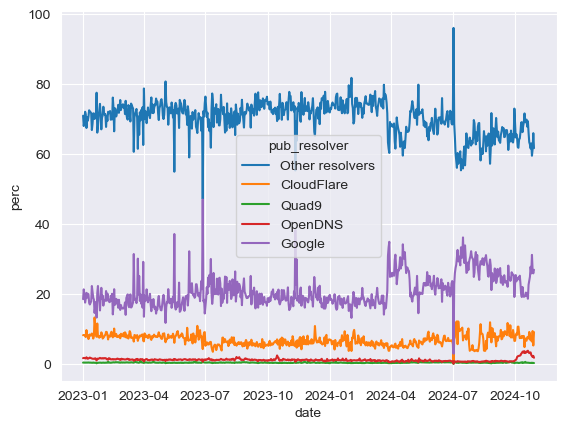

In [18]:
sns.lineplot(data=d0, x='date', y='perc', hue='pub_resolver')

In [21]:
d2 = pd.read_csv('nl-public-dns-providers.csv').melt(id_vars=['DateTime'])

In [22]:
d2.head(2)

,DateTime,variable,value
0,2018-03-01 00:00:00,Other resolvers,NaN
1,2018-03-02 00:00:00,Other resolvers,NaN


<Axes: xlabel='DateTime', ylabel='value'>

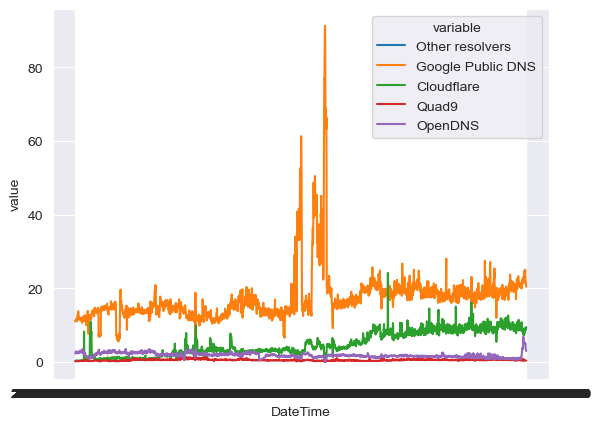

In [24]:
sns.lineplot(data=d2, x='DateTime', y='value', hue='variable')